In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.utils import load_sweep_metadata, load_data
import pandas as pd
import torch


In [ ]:
from analysis.utils import load_sweep_metadata, load_data

CKPT_TO_USE = 500_000
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-23-cartpole_swingup-projected_sweep_uniform_data",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-23-cartpole_swingup-projected_sweep_uniform_data: 100%|██████████| 258/258 [00:00<00:00, 337.44it/s]


Found 256 configurations
Found 256 configurations


100%|██████████| 256/256 [00:03<00:00, 67.25it/s]


In [4]:
df['method_name'] = df['config_name'].apply(lambda x: x.split('_')[0])

In [8]:
df['method_name'].unique()

array(['pca', 'hybrid', 'baseline', 'state', 'nonlinear', 'cca'],
      dtype=object)

In [9]:
df['angle_degrees'] = df['initial_state'].apply(lambda x: int(np.degrees(x[1])))


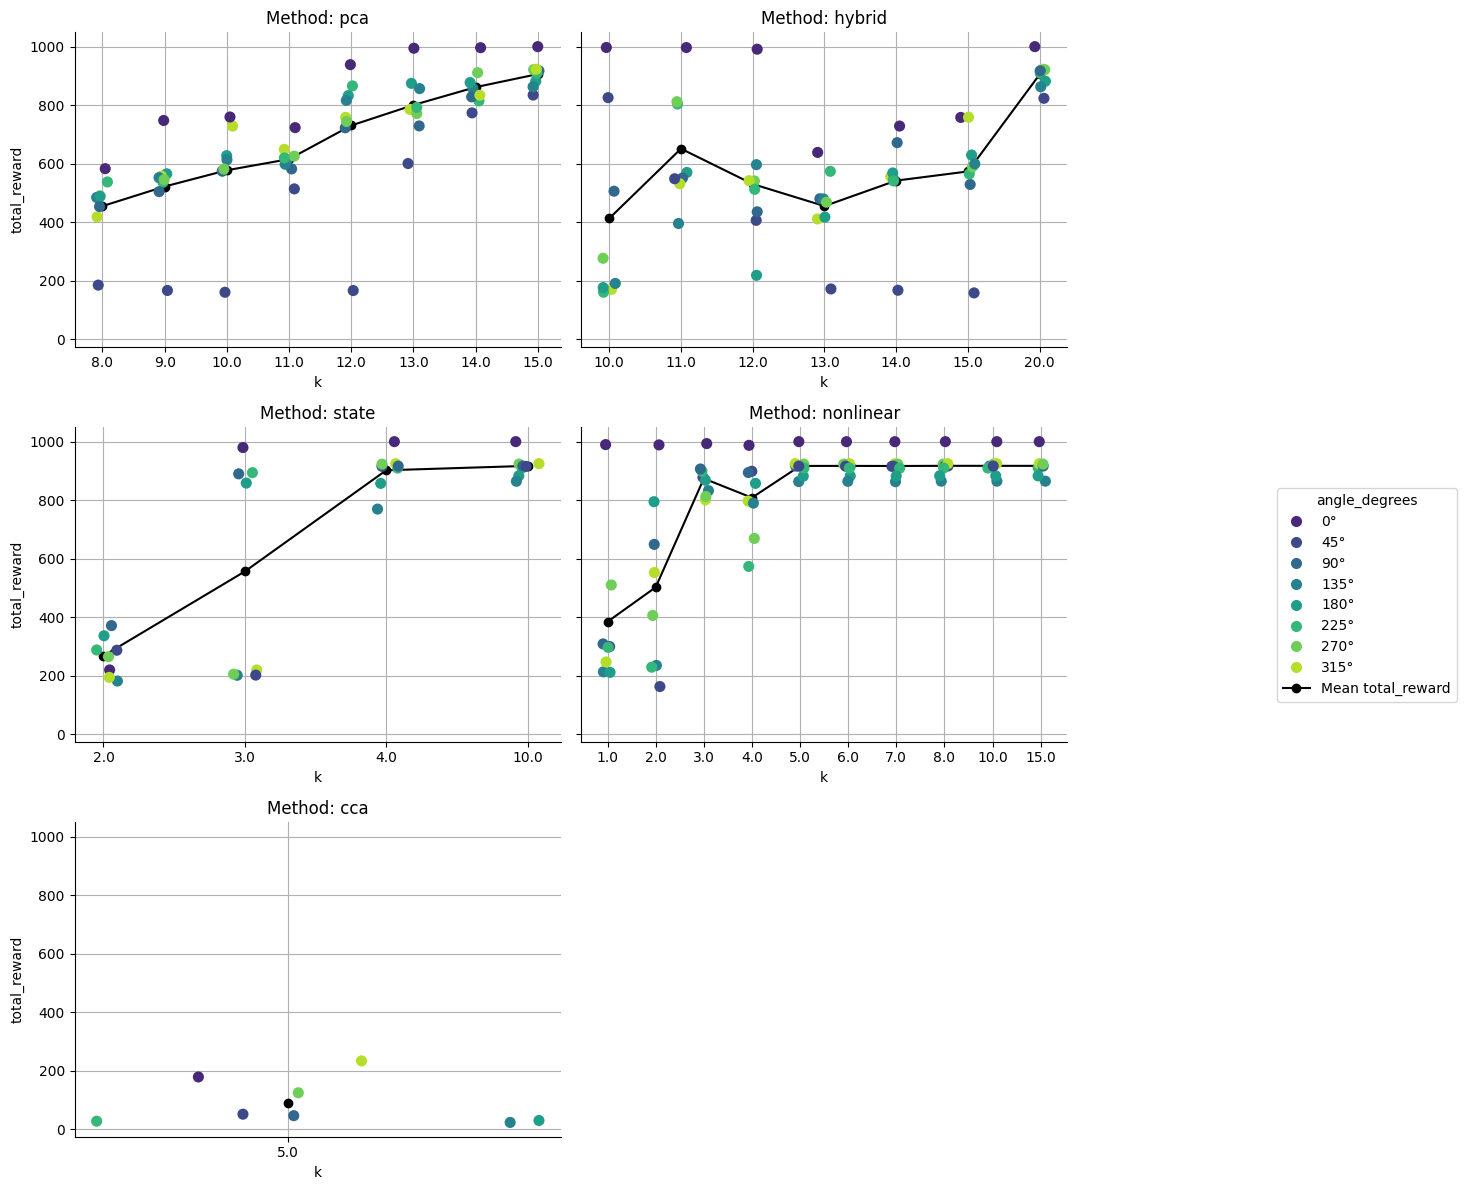

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Filter out 'baseline' method
methods_to_plot = [
    m for m in df['method_name'].unique() if m.lower() != 'baseline'
]

n_methods = len(methods_to_plot)
n_cols = 2
n_rows = (n_methods + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols + 2.5, 4 * n_rows),  # Add width for legend
    sharey=True)

# Flatten in case axes is 2D, also works if 1D
axes = axes.flatten() if n_methods > 1 else [axes]

# --- Order angle categories ---
# Get sorted unique angles
unique_angles_ordered = sorted(df['angle_degrees'].unique())
angle_labels_ordered = [f"{int(a)}°" for a in unique_angles_ordered]

# Categorize angle_degrees with ordered categories
df['angle_degrees_cat'] = pd.Categorical(
    df['angle_degrees'].astype(int).astype(str) + "°",
    categories=angle_labels_ordered,
    ordered=True)

# For color consistency: generate color palette for unique angles
palette = sns.color_palette('viridis', n_colors=len(unique_angles_ordered))
angle_to_color = dict(zip(angle_labels_ordered, palette))

legend_handles = None
legend_labels = None

for idx, (ax, method) in enumerate(zip(axes, methods_to_plot)):
    method_df = df[df['method_name'] == method]

    # Determine the sorted order used for x-axis positions (identical to stripplot's order)
    k_order = sorted(method_df['projector_config_k'].unique())

    # Use seaborn stripplot
    strip = sns.stripplot(x='projector_config_k',
                          y='total_reward',
                          hue='angle_degrees_cat',
                          palette=angle_to_color,
                          data=method_df,
                          ax=ax,
                          dodge=False,
                          jitter=True,
                          size=8,
                          order=k_order,
                          hue_order=angle_labels_ordered,
                          legend=(idx == 0))

    # Synchronize line plot x values with the categorical order of the stripplot:
    # Determine x-tick locations used by stripplot
    xticks = np.arange(len(k_order))

    # Calculate mean total_reward for each k (across all angles) for this method
    # Ensure the mean_rewards index follows the same order as k_order
    mean_rewards = (method_df.groupby('projector_config_k')
                    ['total_reward'].mean().reindex(k_order).reset_index())

    # Manually set x values as integer positions aligned with stripplot's categorical x-ticks
    ax.plot(xticks,
            mean_rewards['total_reward'],
            color='black',
            linestyle='-',
            marker='o',
            label='Mean total_reward')

    # Adjust x-axis: set correct tick positions and labels
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(k) for k in k_order])

    ax.set_xlabel('k')
    ax.set_ylabel('total_reward')
    ax.set_title(f"Method: {method}")
    ax.grid(True)
    sns.despine(ax=ax)

    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Hide unused subplots if any
for ax in axes[n_methods:]:
    ax.set_visible(False)

# Put the legend to the right of the last visible axis
fig.legend(
    legend_handles,
    legend_labels,
    title="angle_degrees",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)
plt.tight_layout(rect=[0, 0, 0.87, 1])  # shrink to keep legend visible
plt.show()

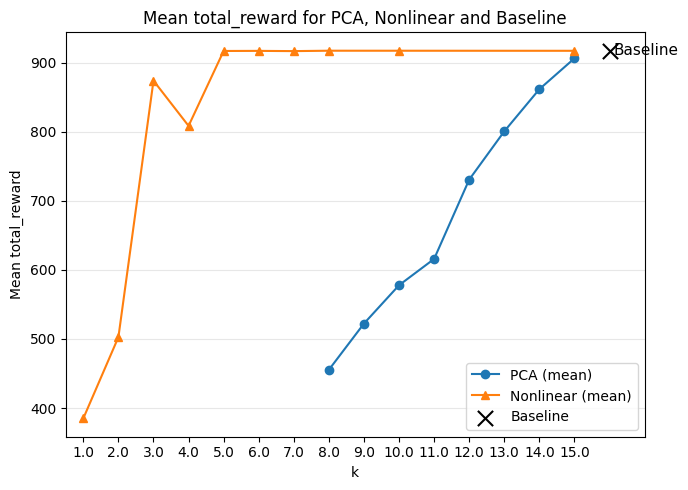

In [11]:
import matplotlib.pyplot as plt

# Separate the DataFrame into PCA and nonlinear projector results
pca_mask = df['method_name'] == 'pca'
nonlinear_mask = df['method_name'] == 'nonlinear'
baseline_mask = df['method_name'] == 'baseline'

df_pca = df[pca_mask]
df_nonlinear = df[nonlinear_mask]
df_baseline = df[baseline_mask]

# Figure out available k values for each method (assume these are correct and sorted)
k_order_pca = sorted(df_pca['projector_config_k'].unique())
k_order_nonlinear = sorted(df_nonlinear['projector_config_k'].unique())

# Compute mean reward for each k for each method
pca_means = df_pca.groupby('projector_config_k')['total_reward'].mean().reindex(
    k_order_pca)
nonlinear_means = df_nonlinear.groupby(
    'projector_config_k')['total_reward'].mean().reindex(k_order_nonlinear)

# Baseline performance (state-based agent/no projection): use df_baseline
baseline_value = None
if not df_baseline.empty:
    baseline_value = df_baseline['total_reward'].mean()

fig, ax = plt.subplots(figsize=(7, 5))

# Set all x-ticks and labels for both PCA and nonlinear (combine, if some overlap in k, otherwise just concatenate)
all_ks = sorted(set(k_order_pca).union(set(k_order_nonlinear)))
all_xticks = range(len(all_ks))
all_xticklabels = [str(k) for k in all_ks]
ax.set_xticks(all_xticks)
ax.set_xticklabels(all_xticklabels)
ax.set_xlabel('k')
ax.set_ylabel('Mean total_reward')


# Align x position for pca and nonlinear based on all_ks index
def ks_to_xticks(ks):
    k_to_x = {k: i for i, k in enumerate(all_ks)}
    return [k_to_x[k] for k in ks]


# Plot mean rewards for PCA (solid line with circles)
ax.plot(ks_to_xticks(k_order_pca),
        pca_means.values,
        marker='o',
        color='C0',
        linestyle='-',
        label='PCA (mean)')

# Plot mean rewards for nonlinear (solid line with triangles)
ax.plot(ks_to_xticks(k_order_nonlinear),
        nonlinear_means.values,
        marker='^',
        color='C1',
        linestyle='-',
        label='Nonlinear (mean)')

# Plot baseline as horizontal 'x' cross at the rightmost x location (after last 'k')
if baseline_value is not None:
    right_x = len(all_ks)  # place it just to the right of the last bar
    ax.scatter(right_x,
               baseline_value,
               marker='x',
               s=120,
               color='black',
               label='Baseline',
               zorder=5)
    # Annotate
    ax.text(right_x + 0.1, baseline_value, 'Baseline', va='center', fontsize=11)

    # Extend xlim so cross is visible
    ax.set_xlim(-0.5, right_x + 1)

# Add grid, legend, and title
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
ax.set_title("Mean total_reward for PCA, Nonlinear and Baseline")
plt.tight_layout()
plt.show()

In [14]:
obs_uniform_data = np.load(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/obs_uniform_30k.npy'
)

In [15]:
obs_uniform_data.shape

(30000, 5)

## Load projector

In [28]:
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector, SupervisedNonlinearLatentProjector

In [30]:
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [31]:
from tdmpc2 import TDMPC2

In [32]:
# Base configuration for state-based environment

CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [ ]:
obs_uniform_torch = torch.from_numpy(obs_uniform_data).to('cuda').float()
z_torch = agent_state.model.encode(obs_uniform_torch, task=None).detach().cpu()
obs_torch = obs_uniform_torch.detach().cpu()

In [34]:
z_torch.shape

torch.Size([30000, 512])

In [38]:
projector = SupervisedNonlinearLatentProjector.load(
    str('/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/state_supervised_nonlinear_projector_k4.pt'
       ))

z_proj, h = projector.project_and_components(z_torch)
#results_k[config['k']] = {'z_proj': z_proj, 'h': h, 'projector': projector}

SupervisedNonlinearLatentProjector loaded: k=4, latent_dim=512, state_dim=5


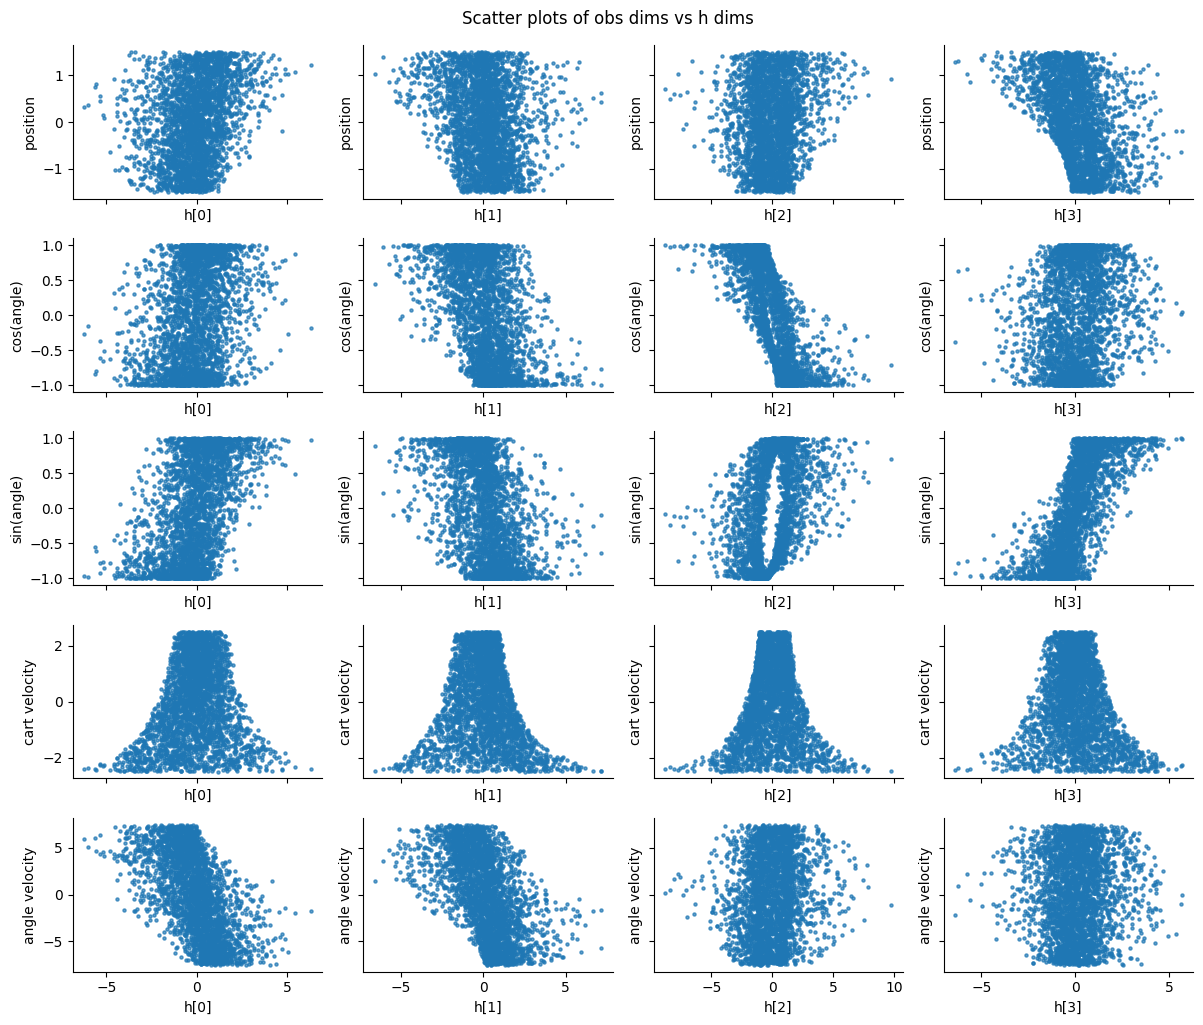

In [40]:
import matplotlib.pyplot as plt

obs_variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angle velocity'
}

obs_plot = obs_torch[:3_000]
h_plot = h[:3_000]

num_obs_dim = obs_plot.shape[1]
num_h_dim = h_plot.shape[1]

fig, axes = plt.subplots(
    num_obs_dim,
    num_h_dim,
    figsize=(3 * num_h_dim, 2 * num_obs_dim),
    sharex='col',  # share x-axis among columns (each h dim)
    sharey='row'  # share y-axis among rows (each obs dim)
)

for i in range(num_obs_dim):
    for j in range(num_h_dim):
        ax = axes[i, j] if num_obs_dim > 1 and num_h_dim > 1 else (
            axes[j] if num_obs_dim == 1 else axes[i])
        x = h_plot[:, j].cpu() if hasattr(h_plot[:, j], 'cpu') else h_plot[:, j]
        y = obs_plot[:, i]
        ax.scatter(x, y, s=5, alpha=0.7)
        ax.set_xlabel(f'h[{j}]')
        ax.set_ylabel(f'{obs_variable_names[i]}')

        # despine
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.suptitle("Scatter plots of obs dims vs h dims", y=1.02)
plt.show()